In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [4]:
def r_int_to_cm(r):
    return r*5.11e12
def m_int_to_g(M):
    return M*2e33
def t_int_to_s(t):
    return t*1e6
def v_int_to_cms(v):
    return v*5.11e6

In [101]:
data = pd.read_csv('2b_output.txt', sep=' ', header=None, names=range(7))
data.columns = ['m','x','y','z','vx','vy','vz']

In [102]:
print(data)

                    m             x             y    z           vx  \
0            2.000000           NaN           NaN  NaN          NaN   
1            0.000002           NaN           NaN  NaN          NaN   
2            1.000000  1.584148e-01  4.286927e-03  0.0  1061.894031   
3      1000000.000000 -1.584148e-07 -4.286927e-09  0.0    -0.001062   
4            2.000000           NaN           NaN  NaN          NaN   
...               ...           ...           ...  ...          ...   
21719  1000000.000000 -1.555391e-07  2.236760e-09  0.0    -0.001167   
21720        2.000000           NaN           NaN  NaN          NaN   
21721        0.000545           NaN           NaN  NaN          NaN   
21722        1.000000  1.574375e-01  2.000551e-03  0.0  1098.150240   
21723  1000000.000000 -1.574375e-07 -2.000551e-09  0.0    -0.001098   

                vy   vz  
0              NaN  NaN  
1              NaN  NaN  
2      2526.424222  0.0  
3        -0.002526  0.0  
4              Na

In [103]:
time_rows = data[data.index % 4 -1 == 0]
times = (time_rows['m'])

m1_rows = data[data.index % 4 -2 == 0]
print(m1_rows['x'])
m2_rows = data[data.index % 4 -3 == 0]

2        0.158415
6        0.158415
10       0.158415
14       0.158415
18       0.158415
           ...   
21706    0.155539
21710    0.155539
21714    0.155539
21718    0.155539
21722    0.157437
Name: x, Length: 5431, dtype: float64


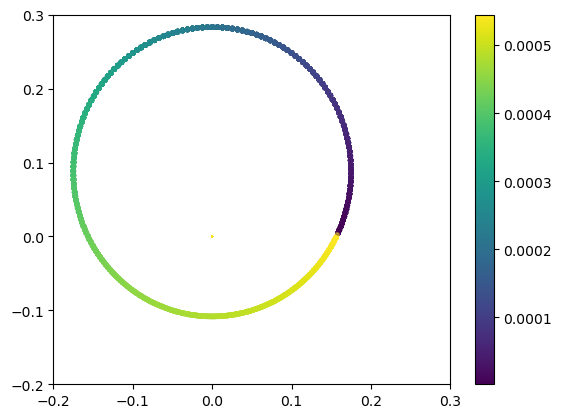

In [104]:
color = times
plt.scatter(m1_rows['x'],m1_rows['y'], c=color,  marker='.', alpha=0.5)
#plt.plot(m1_rows['x'],m1_rows['y'],  marker='.', alpha=1)

plt.scatter(m2_rows['x'],m2_rows['y'], c=color, s=0.1, alpha=1)
plt.xlim(-0.2,0.3)
plt.ylim(-0.2,0.3)
plt.colorbar()


In [100]:
x1 = np.array(m1_rows['x'])
x2 = np.array(m2_rows['x'])
y1 = np.array(m1_rows['y'])
y2 = np.array(m2_rows['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

print(aper)




0.10817743910715849


In [86]:
print((-aper+aapo)/(aper+aapo))

#print(r_int_to_cm((aper+aapo))

0.9165109760622036


In [9]:
M = m1_rows.iloc[0]['m'] + m2_rows.iloc[0]['m']
mu = (m1_rows.iloc[0]['m'] * m2_rows.iloc[0]['m'])/M

In [10]:
def theta(x1,y1,x2,y2):
    return np.arctan((y1-y2)**2/(x1-x2)**2)
def r(x1, y1, x2, y2):
    return (x1-x2)**2 + (y1-y2)**2


In [11]:
vtheta = theta(m1_rows['x'],m1_rows['y'],m2_rows['x'],m2_rows['y'])
vr = r(m1_rows['x'],m1_rows['y'],m2_rows['x'],m2_rows['y'])

In [12]:
vir = v_int_to_cms(r(0.23, 0, -0.23, 0))
print(vir)

1081276.0


In [13]:
sep = r_int_to_cm(r(0.9700436,  -0.24308753,  -0.9700436,   0.24308753))
print(sep/7e10)

292.0222308775986
